# Module Overview Generator

This notebook generates a comprehensive overview of LemonTree modules with MegaGO-based network visualization.

**Output Files:**
- `Module_Overview_Complete.csv` - Comprehensive module data table
- `Module_Network_MegaGO_Interactive.html` - Interactive MegaGO network visualization
- `Module_Network_Complete_Data.json` - Complete network data

## Features

1. **Coherence Filtering**: Only processes modules that pass coherence filtering (threshold ≥ 0.6)
2. **EnrichR Integration**: Uses EnrichR pathway enrichment results with adjusted p-values
3. **Expression Prioritization**: Mann-Whitney U test for differential expression analysis (UC vs nonIBD)
4. **Interactive Visualization**: Network plot showing module-regulator relationships
5. **Statistical Testing**: Documents which statistical tests were used and displays adjusted p-values

## Output

- Comprehensive module overview CSV with expression prioritization
- Interactive network visualization 
- Module prioritization rankings based on differential expression

In [1]:
# Import Required Libraries
import pandas as pd
import os
from scipy.stats import mannwhitneyu
import networkx as nx
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define Input File Paths and Configuration
# You may need to adjust these paths based on your directory structure

# Working directory - change this to match your setup

base_dir = '/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree'

os.chdir('/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree')


# Configuration parameters
percentile = 2  # Fold cutoff used in regulator selection
modules_name = 'selected_86'
coherence_threshold = 0.5  # Minimum module coherence score to retain modules (same as LemonTree_to_network)

# Expression prioritization configuration (should match LemonTree_to_network settings)
prioritize_by_expression = True  # Use expression-based prioritization from LemonTree_to_network
condition1 = 'UC'  # First condition for differential expression
condition2 = 'nonIBD'  # Second condition for differential expression

# Core data files
clusterfile = './ModuleViewer_files/clusters_list.txt'
TF_regulator_file = './ModuleViewer_files/Lovering.percentile' + str(percentile) + '_list.txt'
metabolite_regulator_file = './ModuleViewer_files/Metabolite.percentile' + str(percentile) + '_list.txt'

# Module coherence scores (generated by LemonTree_to_network.ipynb)
coherence_scores_file = 'Module_coherence_scores.txt'

# Expression and metadata files (for prioritization)
expression_complete = './Preprocessing/LemonPreprocessed_complete.txt'
DESeq_groups = './Preprocessing/DESeq_groups.txt'

# Pathway enrichment files - using EnrichR results with adjusted p-values
enrichment_up_file = './Enrichment/Modules_enrichr/Enrichr_top_10_enriched_pathways_up_per_module.csv'
enrichment_down_file = './Enrichment/Modules_enrichr/Enrichr_top_10_enriched_pathways_down_per_module.csv'

print("Configuration set successfully!")
print(f"Base directory: {base_dir}")
print(f"Coherence threshold: {coherence_threshold}")
print(f"Expression prioritization: {prioritize_by_expression}")
if prioritize_by_expression:
    print(f"Comparing {condition1} vs {condition2}")
print(f"Percentile cutoff: {percentile}")
print(f"Module set: {modules_name}")

Configuration set successfully!
Base directory: /home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree
Coherence threshold: 0.5
Expression prioritization: True
Comparing UC vs nonIBD
Percentile cutoff: 2
Module set: selected_86


In [3]:
# get list of modules_to_process
network = pd.read_csv(f'./Networks/LemonNetwork_percentile{percentile}_{modules_name}modules.txt', sep='\t', index_col=False)
modules_to_process = network['Lemon_module'].unique().tolist()
print(modules_to_process)
print(len(modules_to_process))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77, 78, 79, 81, 82, 83, 84, 85, 86, 91, 93, 94, 95]
86


In [4]:
# Function to Parse Regulator and Gene Lists into Dictionaries

def get_regulators(regfile):
    """
    Parse regulator/gene list files into dictionaries.
    
    Parameters:
    regfile (str): Path to the regulator/gene list file
    
    Returns:
    dict: Dictionary mapping module IDs to lists of regulators/genes
    """
    regs = {}
    try:
        with open(regfile) as f:
            for line in f:
                if line.strip():  # Skip empty lines
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        module = parts[0].strip()
                        regulators = parts[1].rstrip().split('|')
                        regs[module] = regulators
    except FileNotFoundError:
        print(f"Warning: File {regfile} not found. Creating empty dictionary.")
        regs = {}
    except Exception as e:
        print(f"Error reading {regfile}: {e}")
        regs = {}
    
    return regs

print("Function get_regulators() defined successfully!")

Function get_regulators() defined successfully!


In [5]:
# Load Module-Regulator and Module-Gene Mappings

# Load regulator assignments for each module
module2TFs = get_regulators(TF_regulator_file)

module2mets = get_regulators(metabolite_regulator_file)
module2genes = get_regulators(clusterfile)

print("Module-Regulator Mappings Loaded:")
print(f"- TF regulators: {len(module2TFs)} modules")

print(f"- Metabolite regulators: {len(module2mets)} modules")
print(f"- Gene clusters: {len(module2genes)} modules")

# Display sample data
if module2genes:
    sample_module = list(module2genes.keys())[0]
    print(f"\nSample module {sample_module}:")
    print(f"- Genes: {module2genes[sample_module][:5]}..." if len(module2genes[sample_module]) > 5 else f"- Genes: {module2genes[sample_module]}")
    if sample_module in module2mets:
        print(f"- Metabolites: {module2mets[sample_module]}")
    if sample_module in module2TFs:
        print(f"- TFs: {module2TFs[sample_module]}")

Module-Regulator Mappings Loaded:
- TF regulators: 97 modules
- Metabolite regulators: 97 modules
- Gene clusters: 97 modules

Sample module 0:
- Genes: ['IL27RA', 'IL21R', 'CD28', 'PPP1R18', 'SASH3']...
- Metabolites: ['C20_1_LPC', 'C14_carnitine', 'C22_1_SM', 'C36_4_PC_plasmalogen', 'C16_1_SM', 'C18_0_LPE_A', 'C20_0_LPE', 'C16_1_LPC_plasmalogen', 'C20_0_SM', 'C18_1_SM']
- TFs: ['SP140']


In [6]:
# Module Prioritization by Expression (adapted from LemonTree_to_network.ipynb)

def prioritize_modules_expression(condition1='UC', condition2='nonIBD', modules_dict=None):
    """
    Prioritize modules based on differential expression between conditions
    Adapted from LemonTree_to_network.ipynb for IBD data
    
    Parameters:
    - condition1: First condition for comparison (default: 'UC')
    - condition2: Second condition for comparison (default: 'nonIBD') 
    - modules_dict: Dictionary mapping module IDs to gene lists
    
    Returns:
    - Dictionary of modules ordered by p-values (ascending)
    """
    
    try:
        # Load sample mapping from metadata - using exact logic from LemonTree_to_network.ipynb
        print("Loading sample annotations...")
        annotations = pd.read_csv(DESeq_groups, sep='\t')
        
        # Add column with sample names if not already present (exact logic from LemonTree_to_network)
        if 'Sample_ID' not in annotations.columns:
            annotations['Sample_ID'] = annotations.index
        print(annotations.head())
        
        # Create dictionary sample_mapping with Sample_ID as keys and diagnosis as values
        # This matches exactly the approach in LemonTree_to_network.ipynb
        sample_mapping = dict(zip(annotations['Sample_ID'], annotations['diagnosis']))
        print(f"{len(sample_mapping)} samples included in the analysis.")
        print(sample_mapping)
        
        print(f"Conditions found: {set(sample_mapping.values())}")
        
        # Use provided modules_dict or load from module2genes
        if modules_dict is None:
            modules_dict = module2genes.copy()
        
        # Split pipe-separated gene lists into actual lists
        for module in modules_dict:
            if isinstance(modules_dict[module], str):
                modules_dict[module] = modules_dict[module].split('|')
        
        module_p_values = {}
        
        # Load expression data
        print("Loading expression data...")
        expression_data = pd.read_csv(expression_complete, sep='\t')
        
        print(f"Processing {len(modules_dict)} modules for expression prioritization...")
        
        for module in modules_dict:
            genes = modules_dict[module]
            
            # Filter expression data for genes in this module
            data_to_use = expression_data[expression_data['symbol'].isin(genes)]
            
            if len(data_to_use) == 0:
                print(f"Warning: No expression data found for module {module}")
                module_p_values[module] = 1.0  # Assign non-significant p-value
                continue
            
            # Remove non-numeric columns (keep only sample columns)
            # This follows the same logic as LemonTree_to_network.ipynb
            data_to_use = data_to_use.iloc[:, 2:len(data_to_use.columns)-1]  # Remove first two columns like in LemonTree
            
            # Calculate mean expression per sample (average across all genes in module)
            means = data_to_use.mean(axis=0)
            means_df = means.to_frame()
            means_df.columns = ['expression']
            means_df.index.name = 'sample'
            means_df.reset_index(inplace=True)
            
            # Get samples for each condition - exact logic from LemonTree_to_network
            group1_samples = [key for key, value in sample_mapping.items() if value == condition1]
            group2_samples = [key for key, value in sample_mapping.items() if value == condition2]
            
            # Filter expression data for each group
            group1_expression = means_df[means_df['sample'].isin(group1_samples)]
            group2_expression = means_df[means_df['sample'].isin(group2_samples)]
            
            group1 = group1_expression['expression'].tolist()
            group2 = group2_expression['expression'].tolist()
            
            # Perform Mann-Whitney U test (exact same as LemonTree_to_network)
            if len(group1) > 0 and len(group2) > 0:
                stat, p = mannwhitneyu(group1, group2)  # Non-parametric alternative for t test
                module_p_values[module] = p
            else:
                print(f"Warning: Not enough samples for module {module}")
                module_p_values[module] = 1.0
        
        # Sort modules by p-values (ascending - most significant first)
        modules_ordered = {k: v for k, v in sorted(module_p_values.items(), key=lambda item: item[1])}
        
        # Apply FDR correction to p-values
        p_values_list = list(modules_ordered.values())
        _, p_adjusted, _, _ = multipletests(p_values_list, method="fdr_bh")
        modules_ordered_adjusted = dict(zip(modules_ordered.keys(), p_adjusted))
        
        # Create summary DataFrame with both raw and adjusted p-values
        prioritization_df = pd.DataFrame(list(modules_ordered.items()), columns=['Module', 'p_value'])
        prioritization_df['p_adjusted'] = list(modules_ordered_adjusted.values())
        
        # Count significant modules
        sig_count = sum(1 for p in modules_ordered.values() if p < 0.05)
        sig_count_adj = sum(1 for p in p_adjusted if p < 0.05)
        
        print(f"\nModule prioritization by expression completed:")
        print(f"- Total modules: {len(modules_ordered)}")
        print(f"- Significant modules (raw p < 0.05): {sig_count}")
        print(f"- Significant modules (adjusted p < 0.05): {sig_count_adj}")
        print(f"- Statistical test: Mann-Whitney U test")
        print(f"- Conditions compared: {condition1} vs {condition2}")
        print(f"- Multiple testing correction: Benjamini-Hochberg FDR")
        
        # Save prioritization results
        prioritization_df.to_csv('Module_prioritization_expression.csv', index=False)
        print("Results saved to: Module_prioritization_expression.csv")
        
        return modules_ordered, prioritization_df
        
    except Exception as e:
        print(f"Error in expression prioritization: {e}")
        print("Returning modules in original order...")
        return {str(k): 1.0 for k in modules_dict.keys() if modules_dict}, pd.DataFrame()

print("Expression prioritization function defined!")

Expression prioritization function defined!


In [7]:
# Execute Module Prioritization by Expression and Add to Overview

# Configuration for prioritization
prioritize_by_expression = True  # Set to True to enable expression prioritization
condition1 = 'UC'      # First condition
condition2 = 'nonIBD'  # Second condition

if prioritize_by_expression:
    print("Running module prioritization by expression...")
    
    # Run expression prioritization
    expression_order, prioritization_df = prioritize_modules_expression(
        condition1=condition1, 
        condition2=condition2, 
        modules_dict=module2genes
    )
    
    # Create a dictionary for easy lookup of p-values and ranks
    module_pvalues = dict(zip(prioritization_df['Module'], prioritization_df['p_value']))
    module_ranks = {module: idx + 1 for idx, module in enumerate(prioritization_df['Module'])}
    
    print(f"Expression prioritization completed!")
    print(f"Most significant modules (top 5):")
    print(prioritization_df.head())
    
else:
    print("Expression prioritization disabled. Using modules in original order.")
    module_pvalues = {}
    module_ranks = {}

print("Expression prioritization configuration completed!")

Running module prioritization by expression...
Loading sample annotations...
         diagnosis     sex biopsy_location  Age at diagnosis Participant ID  \
CSM5FZ1K        UC  Female          Rectum             290.0          C3003   
CSM5FZ1L        UC  Female           Colon             290.0          C3003   
CSM5FZ1N        UC  Female          Rectum             330.0          C3004   
CSM5FZ1O        UC  Female           Colon             330.0          C3004   
CSM5FZ1R        UC  Female          Rectum             580.0          C3005   

         Sample_ID  
CSM5FZ1K  CSM5FZ1K  
CSM5FZ1L  CSM5FZ1L  
CSM5FZ1N  CSM5FZ1N  
CSM5FZ1O  CSM5FZ1O  
CSM5FZ1R  CSM5FZ1R  
75 samples included in the analysis.
{'CSM5FZ1K': 'UC', 'CSM5FZ1L': 'UC', 'CSM5FZ1N': 'UC', 'CSM5FZ1O': 'UC', 'CSM5FZ1R': 'UC', 'CSM5FZ1S': 'UC', 'CSM5FZ1U': 'UC', 'CSM5FZ1V': 'UC', 'CSM5FZ1W': 'UC', 'CSM5FZ2B': 'UC', 'CSM5FZ2C': 'UC', 'CSM5FZ2H': 'UC', 'CSM5FZ2I': 'UC', 'CSM5FZ2M': 'UC', 'CSM5FZ39': 'nonIBD', 'CSMDRVXL'

In [8]:
# Load Pathway Enrichment Data
try:
    # Try to load EnrichR data (single file, no up/down separation)
    module_enrichment_up = pd.read_csv(enrichment_up_file, sep=',')
    print(f"✓ Loaded EnrichR enrichment data: {len(module_enrichment_up)} entries")
    
    # For EnrichR, we only have one file (no separate up/down like GSEA)
    # Add direction column for consistency with processing pipeline
    module_enrichment_up['direction'] = 'Enriched'
    
    # Try to load down-regulated file (only exists for GSEA, not EnrichR)
    try:
        module_enrichment_down = pd.read_csv(enrichment_down_file, sep=',')
        
        # Check if the down file is empty (EnrichR creates empty placeholder files)
        if module_enrichment_down.empty or len(module_enrichment_down.columns) == 0:
            raise ValueError("Down-regulated file is empty")
            
        module_enrichment_down['direction'] = 'Down'
        
        # Combine both datasets if down file exists and has data
        module_enrichment = pd.concat([module_enrichment_up, module_enrichment_down])
        print(f"✓ Also loaded down-regulated pathways: {len(module_enrichment_down)} entries")
        
    except (FileNotFoundError, ValueError, pd.errors.EmptyDataError) as e:
        # Down-regulated file doesn't exist, is empty, or has no columns (normal for EnrichR)
        module_enrichment = module_enrichment_up.copy()
        print("ℹ Down-regulated pathway file not found or empty (normal for EnrichR)")
    
    # Create combined term-direction column
    module_enrichment['Term_direction'] = module_enrichment['Term'] + '_' + module_enrichment['direction']
    
    print("\nPathway Enrichment Data Loaded Successfully:")
    print(f"- Total entries: {len(module_enrichment)} entries")
    print(f"- Unique modules: {module_enrichment['Module'].nunique()}")
    print(f"- Databases available: {list(module_enrichment['Database'].unique())}")
    print(f"- Directions: {list(module_enrichment['direction'].unique())}")
    
    # Display sample of the data
    print("\nSample enrichment data:")
    print(module_enrichment.head(3)[['Module', 'Term', 'Database', 'p.adjust', 'direction']])
    
    enrichment_available = True
    
except FileNotFoundError as e:
    print(f"Warning: EnrichR enrichment file not found: {e}")
    print("Continuing without pathway enrichment data...")
    module_enrichment = pd.DataFrame()
    enrichment_available = False
    
except Exception as e:
    print(f"Error loading enrichment data: {e}")
    print("Continuing without pathway enrichment data...")
    module_enrichment = pd.DataFrame()
    enrichment_available = False

✓ Loaded EnrichR enrichment data: 1543 entries
ℹ Down-regulated pathway file not found or empty (normal for EnrichR)

Pathway Enrichment Data Loaded Successfully:
- Total entries: 1543 entries
- Unique modules: 74
- Databases available: ['BP', 'MF', 'CC', 'KEGG', 'Reactome']
- Directions: ['Enriched']

Sample enrichment data:
   Module                                               Term Database  \
0       0     B Cell Receptor Signaling Pathway (GO:0050853)       BP   
1       0  Antigen Receptor-Mediated Signaling Pathway (G...       BP   
2       0  Positive Regulation of Cytokine Production (GO...       BP   

       p.adjust direction  
0  3.524430e-11  Enriched  
1  4.362685e-09  Enriched  
2  2.118877e-07  Enriched  


In [9]:
# Load PPI Enrichment Data
try:
    ppi_enrichment_file = './ModuleViewer_files/PPI_enrichment_results.csv'
    ppi_enrichment_df = pd.read_csv(ppi_enrichment_file)
    print(f"✓ Loaded PPI enrichment data: {len(ppi_enrichment_df)} modules")
    
    # Create dictionary for easy lookup
    module2ppi = {}
    for _, row in ppi_enrichment_df.iterrows():
        # Convert to int first to remove .0, then to string for consistent lookup
        module_id = str(int(row['Module']))
        module2ppi[module_id] = {
            'PPI_p_value': row['P_value'],
            'PPI_FDR': row['FDR'],
            'PPI_fold_enrichment': row['Fold_enrichment'],
            'PPI_observed': row['N_PPIs_observed'],
            'PPI_expected': row['N_PPIs_expected']
        }
    
    print(f"\nPPI Enrichment Summary:")
    n_significant = (ppi_enrichment_df['FDR'] < 0.05).sum()
    print(f"- Modules significantly enriched for PPIs (FDR < 0.05): {n_significant}")
    print(f"- Mean fold enrichment: {ppi_enrichment_df['Fold_enrichment'].mean():.2f}")
    
    ppi_enrichment_available = True
    
except FileNotFoundError as e:
    print(f"Warning: PPI enrichment file not found: {e}")
    print("Continuing without PPI enrichment data...")
    module2ppi = {}
    ppi_enrichment_available = False
    
except Exception as e:
    print(f"Error loading PPI enrichment data: {e}")
    print("Continuing without PPI enrichment data...")
    module2ppi = {}
    ppi_enrichment_available = False

✓ Loaded PPI enrichment data: 97 modules

PPI Enrichment Summary:
- Modules significantly enriched for PPIs (FDR < 0.05): 33
- Mean fold enrichment: 3.62


In [10]:
# Parse Pathway Enrichment Data into Dictionaries

if enrichment_available and not module_enrichment.empty:
    # Initialize dictionaries for different pathway databases
    # Two sets: top 3 for overview file, top 10 for megaGO clustering
    module2BP = {}
    module2MF = {}
    module2CC = {}
    module2KEGG = {}
    module2Reactome = {}
    
    print("Processing pathway enrichment data...")
    
    for module in module_enrichment['Module'].unique():
        data = module_enrichment[module_enrichment['Module'] == module]
        
        # Filter by database type
        BP = data[data['Database'] == 'BP']
        MF = data[data['Database'] == 'MF']
        CC = data[data['Database'] == 'CC']
        KEGG = data[data['Database'] == 'KEGG']
        Reactome = data[data['Database'] == 'Reactome']
        
        # Sort by adjusted p-value (most significant first)
        BP = BP.sort_values(by='p.adjust', ascending=True)
        MF = MF.sort_values(by='p.adjust', ascending=True)
        CC = CC.sort_values(by='p.adjust', ascending=True)
        KEGG = KEGG.sort_values(by='p.adjust', ascending=True)
        Reactome = Reactome.sort_values(by='p.adjust', ascending=True)
        
        # Take the top 3 most significant pathways for each database (for overview file)
        module2BP[module] = BP[:3]['Term_direction'].tolist()
        module2MF[module] = MF[:3]['Term_direction'].tolist()
        module2CC[module] = CC[:3]['Term_direction'].tolist()
        module2KEGG[module] = KEGG[:3]['Term_direction'].tolist()
        module2Reactome[module] = Reactome[:3]['Term_direction'].tolist()
        

    print("Pathway Enrichment Dictionaries Created:")
    print(f"- Biological Process (BP): {len(module2BP)} modules")
    print(f"- Molecular Function (MF): {len(module2MF)} modules")
    print(f"- Cellular Component (CC): {len(module2CC)} modules")
    print(f"- KEGG: {len(module2KEGG)} modules")
    print(f"- Reactome: {len(module2Reactome)} modules")
    

    
    # Show example comparison
    if module2BP:
        sample_module = list(module2BP.keys())[0]
        print(f"\nExample for module {sample_module}:")
        print(f"- MF (top 3): {module2MF[sample_module]}")
        
else:
    print("Creating empty pathway dictionaries (no enrichment data available)...")
    module2BP = {}
    module2MF = {}
    module2CC = {}
    module2KEGG = {}
    module2Reactome = {}
    
    # Empty megaGO dictionaries as well
    module2BP_megago = {}
    module2MF_megago = {}
    module2CC_megago = {}
    module2KEGG_megago = {}
    module2Reactome_megago = {}

Processing pathway enrichment data...
Pathway Enrichment Dictionaries Created:
- Biological Process (BP): 74 modules
- Molecular Function (MF): 74 modules
- Cellular Component (CC): 74 modules
- KEGG: 74 modules
- Reactome: 74 modules

Example for module 0:
- MF (top 3): ['GTPase Regulator Activity (GO:0030695)_Enriched', 'Non-Membrane Spanning Protein Tyrosine Kinase Activity (GO:0004715)_Enriched', 'Small GTPase Binding (GO:0031267)_Enriched']


In [11]:
# Create comprehensive module overview with all data types

module_data = []

# Load expression prioritization data if available
if prioritize_by_expression:
    module_pvalues = expression_order
    # Create rank mapping (1 = most significant)
    sorted_modules = sorted(expression_order.items(), key=lambda x: x[1])
    module_ranks = {module: rank + 1 for rank, (module, _) in enumerate(sorted_modules)}
    print(f"Expression prioritization data loaded: {len(module_pvalues)} modules")
else:
    module_pvalues = {}
    module_ranks = {}

for module in modules_to_process:
    # Safely retrieve data for each module, use 'NA' if missing
    TFs = module2TFs.get(str(module), 'NA')
    mets = module2mets.get(str(module), 'NA')
    genes = module2genes.get(str(module), 'NA')
    
    # Convert lists to pipe-separated strings for readability
    if isinstance(TFs, list):
        TFs = '|'.join(TFs) if TFs != [''] else 'NA'
    if isinstance(mets, list):
        mets = '|'.join(mets) if mets != [''] else 'NA'
    if isinstance(genes, list):
        genes = '|'.join(genes) if genes != [''] else 'NA'
    
    # Get expression prioritization data
    expression_p_value = module_pvalues.get(str(module), 'NA')
    expression_rank = module_ranks.get(str(module), 'NA')
    expression_significant = 'Yes' if (expression_p_value != 'NA' and expression_p_value < 0.05) else 'No'
    if expression_p_value == 'NA':
        expression_significant = 'NA'
    
    # Get pathway enrichment data (try both int and str module IDs)
    try:
        module_int = int(module)
        BP = module2BP.get(module_int, module2BP.get(str(module), 'NA'))
        MF = module2MF.get(module_int, module2MF.get(str(module), 'NA'))
        CC = module2CC.get(module_int, module2CC.get(str(module), 'NA'))
        KEGG = module2KEGG.get(module_int, module2KEGG.get(str(module), 'NA'))
        Reactome = module2Reactome.get(module_int, module2Reactome.get(str(module), 'NA'))
    except ValueError:
        # Module ID is not a number
        BP = module2BP.get(str(module), 'NA')
        MF = module2MF.get(str(module), 'NA')
        CC = module2CC.get(str(module), 'NA')
        KEGG = module2KEGG.get(str(module), 'NA')
        Reactome = module2Reactome.get(str(module), 'NA')
    
    # Handle different data types for pathways
    for pathway_data in [BP, MF, CC, KEGG, Reactome]:
        if isinstance(pathway_data, list):
            pathway_data = '|'.join(pathway_data) if pathway_data != [''] else 'NA'
    
    # Ensure pathways are strings
    BP = str(BP) if BP != 'NA' else 'NA'
    MF = str(MF) if MF != 'NA' else 'NA'
    CC = str(CC) if CC != 'NA' else 'NA'
    KEGG = str(KEGG) if KEGG != 'NA' else 'NA'
    Reactome = str(Reactome) if Reactome != 'NA' else 'NA'
    
    # Get PPI enrichment data
    ppi_data = module2ppi.get(str(module), {})
    ppi_fdr = ppi_data.get('PPI_FDR', 'NA')
    ppi_fold_enrichment = ppi_data.get('PPI_fold_enrichment', 'NA')
    
    # Create module entry with enhanced data including expression prioritization
    module_entry = {
        'Module': module,
        'TF_regulators': TFs,
        'Metabolite_regulators': mets,
        'Module_genes': genes,
        'Top_3_pathways_bio_process': BP,
        'Top_3_pathways_molecular_function': MF,
        'Top_3_pathways_cellular_component': CC,
        'Top_3_pathways_KEGG': KEGG,
        'Top_3_pathways_Reactome': Reactome
    }
    
    # Add expression prioritization data if available
    if prioritize_by_expression:
        module_entry.update({
            'Expression_p_value': expression_p_value,
            'Expression_rank': expression_rank,
            'Expression_significant': expression_significant
        })
    
    # Add PPI enrichment data if available
    if ppi_enrichment_available:
        module_entry.update({
            'PPI_FDR': ppi_fdr,
            'PPI_fold_enrichment': ppi_fold_enrichment
        })
    
    module_data.append(module_entry)

# Convert to DataFrame with enhanced column ordering
base_columns = [
    'Module', 
    'TF_regulators', 
    'Metabolite_regulators', 
    'Module_genes', 
    'Top_3_pathways_bio_process', 
    'Top_3_pathways_molecular_function', 
    'Top_3_pathways_cellular_component', 
    'Top_3_pathways_KEGG', 
    'Top_3_pathways_Reactome'
]

# Add expression columns if prioritization is enabled
if prioritize_by_expression:
    expression_columns = ['Expression_p_value', 'Expression_rank', 'Expression_significant']
    columns = base_columns[:3] + expression_columns + base_columns[3:]
else:
    columns = base_columns

# Add PPI enrichment columns if available
if ppi_enrichment_available:
    ppi_columns = ['PPI_FDR', 'PPI_fold_enrichment']
    # Insert PPI columns after expression columns (if present) or after metabolite_regulators
    if prioritize_by_expression:
        insert_position = base_columns.index('Module_genes') + len(expression_columns)
        columns = columns[:insert_position] + ppi_columns + columns[insert_position:]
    else:
        insert_position = base_columns.index('Module_genes')
        columns = columns[:insert_position] + ppi_columns + columns[insert_position:]

module_overview = pd.DataFrame(module_data, columns=columns)

# Sort by expression rank if available, otherwise by module number
if prioritize_by_expression and 'Expression_rank' in module_overview.columns:
    # Sort by expression rank (most significant first), then by module number for ties
    module_overview = module_overview.sort_values(['Expression_rank', 'Module']).reset_index(drop=True)
    print(f"\nModule overview sorted by expression significance (UC vs nonIBD)")
else:
    # Sort by module number
    try:
        module_overview['Module'] = pd.to_numeric(module_overview['Module'])
        module_overview = module_overview.sort_values('Module').reset_index(drop=True)
    except:
        pass  # Keep original order if conversion fails

print(f"\nModule Overview Generated:")
print(f"Shape: {module_overview.shape}")
print(f"Columns: {list(module_overview.columns)}")

# Display sample of the data
print(f"\nFirst few entries:")
if prioritize_by_expression and ppi_enrichment_available:
    display_cols = ['Module', 'Expression_p_value', 'Expression_rank', 'Expression_significant', 
                   'PPI_FDR', 'PPI_fold_enrichment', 'TF_regulators', 'Metabolite_regulators']
    print(module_overview[display_cols].head())
elif prioritize_by_expression:
    display_cols = ['Module', 'Expression_p_value', 'Expression_rank', 'Expression_significant', 'TF_regulators', 'Metabolite_regulators']
    print(module_overview[display_cols].head())
elif ppi_enrichment_available:
    display_cols = ['Module', 'PPI_FDR', 'PPI_fold_enrichment', 'TF_regulators', 'Metabolite_regulators']
    print(module_overview[display_cols].head())
else:
    print(module_overview[['Module', 'TF_regulators', 'Metabolite_regulators', 'Module_genes']].head())

# Summary statistics
print(f"\nSummary Statistics:")
tf_count = sum(1 for x in module_overview['TF_regulators'] if x != 'NA')
met_count = sum(1 for x in module_overview['Metabolite_regulators'] if x != 'NA')

print(f"\nRegulator Coverage:")
print(f"- Modules with TF regulators: {tf_count}")
print(f"- Modules with Metabolite regulators: {met_count}")

if ppi_enrichment_available and 'PPI_FDR' in module_overview.columns:
    ppi_available = sum(1 for x in module_overview['PPI_FDR'] if x != 'NA')
    ppi_significant = sum(1 for x in module_overview['PPI_FDR'] if x != 'NA' and x < 0.05)
    
    print(f"\nPPI Enrichment Results:")
    print(f"- PPI enrichment data available for: {ppi_available} modules")
    print(f"- Significantly enriched modules (FDR < 0.05): {ppi_significant}")
    
    if ppi_significant > 0:
        print(f"- Top 5 most enriched modules:")
        top_ppi = module_overview[module_overview['PPI_FDR'] != 'NA'].nsmallest(5, 'PPI_FDR')
        for _, row in top_ppi.iterrows():
            if row['PPI_FDR'] < 0.05:
                print(f"  Module {row['Module']}: FDR = {row['PPI_FDR']:.2e}, Fold enrichment = {row['PPI_fold_enrichment']:.2f}")

if prioritize_by_expression:
    sig_modules = module_overview[module_overview['Expression_significant'] == 'Yes']
    print(f"- Modules with significant differential expression: {len(sig_modules)}")
    
    if len(sig_modules) > 0:
        print(f"\nTop 5 most significant modules:")
        top_significant = sig_modules.head()
        for _, row in top_significant.iterrows():
            print(f"  Module {row['Module']}: p-value = {row['Expression_p_value']:.2e}, rank = {row['Expression_rank']}")

print("\nModule overview completed successfully!")

Expression prioritization data loaded: 97 modules

Module overview sorted by expression significance (UC vs nonIBD)

Module Overview Generated:
Shape: (86, 14)
Columns: ['Module', 'TF_regulators', 'Metabolite_regulators', 'Expression_p_value', 'Expression_rank', 'Expression_significant', 'PPI_FDR', 'PPI_fold_enrichment', 'Module_genes', 'Top_3_pathways_bio_process', 'Top_3_pathways_molecular_function', 'Top_3_pathways_cellular_component', 'Top_3_pathways_KEGG', 'Top_3_pathways_Reactome']

First few entries:
   Module  Expression_p_value  Expression_rank Expression_significant  \
0      49        5.964695e-10                1                    Yes   
1      16        1.699718e-09                2                    Yes   
2      85        1.820852e-09                3                    Yes   
3      23        2.277237e-08                5                    Yes   
4       7        3.134152e-08                6                    Yes   

         PPI_FDR  PPI_fold_enrichment  \
0   5.9

In [12]:
# Save Module Overview DataFrame and Display Summary

# Create output filename with expression info if applicable
if prioritize_by_expression:
    output_filename = f'Module_Overview_Complete_Expression_{condition1}_vs_{condition2}.csv'
else:
    output_filename = 'Module_Overview_Complete.csv'

# Save to CSV file
module_overview.to_csv(output_filename, sep='\t', index=False)
print(f"Module overview saved to: {output_filename}")

# Display summary statistics
print("\n" + "="*60)
print("MODULE OVERVIEW SUMMARY")
print("="*60)

print(f"Total modules processed: {len(module_overview)}")

# Count non-NA entries for each regulator type
tf_count = sum(1 for x in module_overview['TF_regulators'] if x != 'NA')
met_count = sum(1 for x in module_overview['Metabolite_regulators'] if x != 'NA')


print(f"\nRegulator Coverage:")
print(f"- Modules with TF regulators: {tf_count}")
print(f"- Modules with Metabolite regulators: {met_count}")


# Expression prioritization summary
if prioritize_by_expression and 'Expression_p_value' in module_overview.columns:
    expression_available = sum(1 for x in module_overview['Expression_p_value'] if x != 'NA')
    expression_significant = sum(1 for x in module_overview['Expression_significant'] if x == 'Yes')
    
    print(f"\nExpression Prioritization Results:")
    print(f"- Expression data available for: {expression_available} modules")
    print(f"- Significantly different modules (p < 0.05): {expression_significant}")
    print(f"- Conditions compared: {condition1} vs {condition2}")
    
    if expression_significant > 0:
        print(f"- Top 5 most significant modules:")
        top_significant = module_overview[module_overview['Expression_significant'] == 'Yes'].head()
        for _, row in top_significant.iterrows():
            print(f"  Module {row['Module']}: p = {row['Expression_p_value']:.2e} (rank {row['Expression_rank']})")

# PPI enrichment summary
if ppi_enrichment_available and 'PPI_FDR' in module_overview.columns:
    ppi_available = sum(1 for x in module_overview['PPI_FDR'] if x != 'NA')
    ppi_significant = sum(1 for x in module_overview['PPI_FDR'] if x != 'NA' and x < 0.05)
    
    print(f"\nPPI Enrichment Results:")
    print(f"- PPI enrichment data available for: {ppi_available} modules")
    print(f"- Significantly enriched modules (FDR < 0.05): {ppi_significant}")
    
    if ppi_significant > 0:
        print(f"- Top 5 most enriched modules:")
        top_ppi = module_overview[module_overview['PPI_FDR'] != 'NA'].nsmallest(5, 'PPI_FDR')
        for _, row in top_ppi.iterrows():
            if row['PPI_FDR'] < 0.05:
                print(f"  Module {row['Module']}: FDR = {row['PPI_FDR']:.2e}, Fold enrichment = {row['PPI_fold_enrichment']:.2f}")

# Count pathway enrichment coverage
bp_count = sum(1 for x in module_overview['Top_3_pathways_bio_process'] if x != 'NA')
mf_count = sum(1 for x in module_overview['Top_3_pathways_molecular_function'] if x != 'NA')
cc_count = sum(1 for x in module_overview['Top_3_pathways_cellular_component'] if x != 'NA')
kegg_count = sum(1 for x in module_overview['Top_3_pathways_KEGG'] if x != 'NA')
reactome_count = sum(1 for x in module_overview['Top_3_pathways_Reactome'] if x != 'NA')

print(f"\nPathway Enrichment Coverage:")
print(f"- Modules with BP pathways: {bp_count}")
print(f"- Modules with MF pathways: {mf_count}")
print(f"- Modules with CC pathways: {cc_count}")
print(f"- Modules with KEGG pathways: {kegg_count}")
print(f"- Modules with Reactome pathways: {reactome_count}")

# Show a sample of the complete overview
print(f"\n" + "="*60)
print("SAMPLE MODULES FROM OVERVIEW")
print("="*60)

# Display detailed view of first 2 modules
for i in range(min(2, len(module_overview))):
    row = module_overview.iloc[i]
    print(f"\nModule {row['Module']}:")
    print(f"  Genes: {row['Module_genes'][:100]}..." if len(str(row['Module_genes'])) > 100 else f"  Genes: {row['Module_genes']}")
    print(f"  TF regulators: {row['TF_regulators']}")
    print(f"  Metabolite regulators: {row['Metabolite_regulators']}")

    
    # Add expression information if available
    if 'Expression_p_value' in row and row['Expression_p_value'] != 'NA':
        print(f"  Expression p-value: {row['Expression_p_value']:.2e}")
        print(f"  Expression rank: {row['Expression_rank']}")
        print(f"  Significantly different: {row['Expression_significant']}")
    
    # Add PPI enrichment information if available
    if 'PPI_FDR' in row and row['PPI_FDR'] != 'NA':
        print(f"  PPI enrichment FDR: {row['PPI_FDR']:.2e}")
        print(f"  PPI fold enrichment: {row['PPI_fold_enrichment']:.2f}")
    
    print(f"  BP pathways: {row['Top_3_pathways_bio_process']}")
    print(f"  MF pathways: {row['Top_3_pathways_molecular_function']}")

print(f"\n" + "="*60)
print("OVERVIEW GENERATION COMPLETE!")
print(f"Full results saved in: {output_filename}")
if prioritize_by_expression:
    print(f"Modules are ordered by expression significance ({condition1} vs {condition2})")
    print(f"Expression prioritization results also saved in: Module_prioritization_expression.csv")

Module overview saved to: Module_Overview_Complete_Expression_UC_vs_nonIBD.csv

MODULE OVERVIEW SUMMARY
Total modules processed: 86

Regulator Coverage:
- Modules with TF regulators: 86
- Modules with Metabolite regulators: 86

Expression Prioritization Results:
- Expression data available for: 86 modules
- Significantly different modules (p < 0.05): 61
- Conditions compared: UC vs nonIBD
- Top 5 most significant modules:
  Module 49: p = 5.96e-10 (rank 1)
  Module 16: p = 1.70e-09 (rank 2)
  Module 85: p = 1.82e-09 (rank 3)
  Module 23: p = 2.28e-08 (rank 5)
  Module 7: p = 3.13e-08 (rank 6)

PPI Enrichment Results:
- PPI enrichment data available for: 86 modules
- Significantly enriched modules (FDR < 0.05): 30
- Top 5 most enriched modules:
  Module 0: FDR = 0.00e+00, Fold enrichment = 12.47
  Module 4: FDR = 7.16e-270, Fold enrichment = 6.29
  Module 7: FDR = 1.61e-255, Fold enrichment = 6.90
  Module 3: FDR = 1.26e-128, Fold enrichment = 11.12
  Module 10: FDR = 2.10e-88, Fold enr

In [13]:
os.getcwd()

'/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree'

Creating heatmap for top 15 metabolite regulators...
Top 15 metabolite regulators by connectivity:
 1. C18_1_LPC_plasmalogen: 20 modules
 2. C2_carnitine: 17 modules
 3. C14_carnitine: 15 modules
 4. C20_1_LPC: 15 modules
 5. C36_4_PC_plasmalogen: 14 modules
 6. C22_1_SM: 13 modules
 7. adrenate: 11 modules
 8. gabapentin: 10 modules
 9. C18_0_LPC: 9 modules
10. eicosadienoate: 9 modules
11. C18_0_LPE_A: 8 modules
12. alpha_glycerophosphocholine: 8 modules
13. putrescine: 8 modules
14. 5_aminolevulinic_acid: 7 modules
15. C16_0_SM: 7 modules
Found expression p-values for 97 modules
Using adjusted p-values (FDR corrected) for significance testing
Significant modules (adjusted p < 0.05): 53
Significant modules in heatmap: [16, 9, 23, 2, 49, 8, 12, 84, 82, 93, 56, 18, 6, 3, 44, 75, 14, 21, 47, 34, 1, 7, 22, 25, 26, 46, 79, 59, 52, 27, 17, 85, 81, 62, 64, 71, 90, 43, 41, 33, 39, 40, 48, 73, 70, 68, 58, 50, 72, 76, 86, 91, 95]


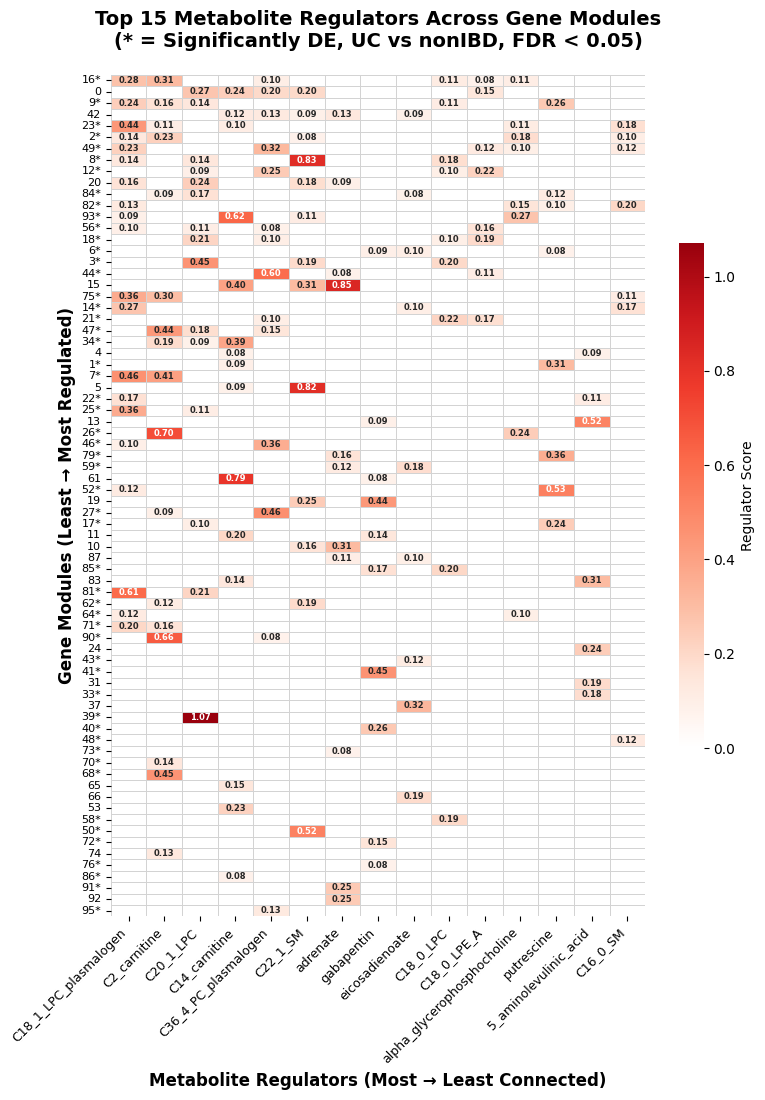


=== HEATMAP SUMMARY ===
Heatmap dimensions: 74 modules × 15 regulators
Score range: 0.078 - 1.071
Number of regulator-module interactions: 171
Significant modules (FDR < 0.05): 53
Figure dimensions: 8 × 11.1 inches

Significant modules with regulators:
  Module 16: 6 regulators
  Module 9: 5 regulators
  Module 23: 5 regulators
  Module 2: 5 regulators
  Module 49: 5 regulators
  Module 8: 4 regulators
  Module 12: 4 regulators
  Module 84: 4 regulators
  Module 82: 4 regulators
  Module 93: 4 regulators
  Module 56: 4 regulators
  Module 18: 4 regulators
  Module 6: 3 regulators
  Module 3: 3 regulators
  Module 44: 3 regulators
  Module 75: 3 regulators
  Module 14: 3 regulators
  Module 21: 3 regulators
  Module 47: 3 regulators
  Module 34: 3 regulators
  Module 1: 2 regulators
  Module 7: 2 regulators
  Module 22: 2 regulators
  Module 25: 2 regulators
  Module 26: 2 regulators
  Module 46: 2 regulators
  Module 79: 2 regulators
  Module 59: 2 regulators
  Module 52: 2 regulators

In [14]:
# Create Heatmap for Top 15 Metabolite Regulators with Significance Marking

import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import numpy as np

print("Creating heatmap for top 15 metabolite regulators...")

# Load regulator-module score data
regulator_file = f'./Lemon_out/Metabolite.percentile{percentile}.txt'
df = pd.read_csv(regulator_file, sep='\t')

# Select only relevant columns
df = df[['Regulator', 'Target', 'Score']]

# Get top 15 regulators based on number of modules they regulate
regulator_module_counts = df.groupby('Regulator')['Target'].nunique().nlargest(15)
top_regulators = regulator_module_counts.index

print(f"Top 15 metabolite regulators by connectivity:")
for i, (reg, count) in enumerate(regulator_module_counts.items(), 1):
    print(f"{i:2d}. {reg}: {count} modules")

# Filter data to keep only top regulators
df_filtered = df[df['Regulator'].isin(top_regulators)]

# Pivot to create a matrix where:
# - Rows = Gene modules (Targets) 
# - Columns = Regulators
# - Values = Scores
heatmap_df = df_filtered.pivot(index='Target', columns='Regulator', values='Score')

# Fill NaN values with 0
heatmap_df = heatmap_df.fillna(0)

# Sort columns by connectivity (number of modules each regulator connects to)
regulator_connectivity = (heatmap_df > 0).sum()  # Count non-zero entries per regulator
col_order = regulator_connectivity.sort_values(ascending=False).index
heatmap_df = heatmap_df[col_order]

# Sort rows by number of regulators per module (most regulated modules first)
module_connectivity = (heatmap_df > 0).sum(axis=1)  # Count non-zero entries per module
row_order = module_connectivity.sort_values(ascending=False).index
heatmap_df = heatmap_df.loc[row_order]

# Create module labels with significance marking using adjusted p-values
# Check if module_pvalues exists from expression prioritization
if 'module_pvalues' in globals() and module_pvalues and 'prioritization_df' in globals():
    print(f"Found expression p-values for {len(module_pvalues)} modules")
    
    # Use adjusted p-values for significance testing
    if 'p_adjusted' in prioritization_df.columns:
        module_pvalues_adj = dict(zip(prioritization_df['Module'], prioritization_df['p_adjusted']))
        print("Using adjusted p-values (FDR corrected) for significance testing")
    else:
        module_pvalues_adj = module_pvalues
        print("Warning: No adjusted p-values found, using raw p-values")
    
    # Create labels with * for significant modules (adjusted p < 0.05)
    module_labels = []
    significant_modules = []
    
    for module in heatmap_df.index:
        module_str = str(module)
        pval_adj = module_pvalues_adj.get(module_str, 1.0)
        
        if pval_adj < 0.05:
            label = f"{module}*"
            significant_modules.append(module)
        else:
            label = str(module)
        module_labels.append(label)
    
    print(f"Significant modules (adjusted p < 0.05): {len(significant_modules)}")
    print(f"Significant modules in heatmap: {significant_modules}")
    
else:
    print("No expression p-values found. Running expression prioritization...")
    
    # Run expression prioritization if not already done
    try:
        expression_order, prioritization_df = prioritize_modules_expression(
            condition1='UC', 
            condition2='nonIBD', 
            modules_dict=module2genes
        )
        module_pvalues = dict(zip(prioritization_df['Module'], prioritization_df['p_value']))
        
        # Use adjusted p-values for significance testing
        if 'p_adjusted' in prioritization_df.columns:
            module_pvalues_adj = dict(zip(prioritization_df['Module'], prioritization_df['p_adjusted']))
            print("Using adjusted p-values (FDR corrected) for significance testing")
        else:
            module_pvalues_adj = module_pvalues
            print("Warning: No adjusted p-values found, using raw p-values")
        
        # Create labels with * for significant modules using adjusted p-values
        module_labels = []
        significant_modules = []
        
        for module in heatmap_df.index:
            module_str = str(module)
            pval_adj = module_pvalues_adj.get(module_str, 1.0)
            
            if pval_adj < 0.05:
                label = f"{module}*"
                significant_modules.append(module)
            else:
                label = str(module)
            module_labels.append(label)
        
        print(f"Significant modules (adjusted p < 0.05): {len(significant_modules)}")
        print(f"Significant modules in heatmap: {significant_modules}")
        
    except Exception as e:
        print(f"Could not run expression prioritization: {e}")
        print("Creating heatmap without significance marking...")
        module_labels = [str(module) for module in heatmap_df.index]
        significant_modules = []

# Create a better color map with more dynamic range
# Use white for 0, light colors for low scores, dark red for high scores
colors = ['white', '#fee5d9', '#fcbba1', '#fc9272', '#fb6a4a', '#ef3b2c', '#cb181d', '#99000d']
cmap = LinearSegmentedColormap.from_list('custom_red', colors)

# Set up the figure with better proportions - make it less wide
n_modules = heatmap_df.shape[0]
fig_height = min(12, max(6, n_modules * 0.15))  # Between 6-12 inches
fig, ax = plt.subplots(figsize=(8, fig_height))

# Create annotations that only show values > 0, formatted to 2 decimal places
annot = heatmap_df.applymap(lambda x: f'{x:.2f}' if x > 0 else '')

# Create the heatmap with improved styling
sns.heatmap(heatmap_df, 
            cmap=cmap, 
            annot=annot, 
            fmt='', 
            linewidths=0.5,
            linecolor='lightgray',
            cbar=True,
            cbar_kws={'label': 'Regulator Score', 'shrink': 0.6},
            annot_kws={'size': 6, 'weight': 'bold'},
            square=False,
            ax=ax)

# Improve the title and labels
plt.title('Top 15 Metabolite Regulators Across Gene Modules\n(* = Significantly DE, UC vs nonIBD, FDR < 0.05)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Metabolite Regulators (Most → Least Connected)', fontsize=12, fontweight='bold')
plt.ylabel('Gene Modules (Least → Most Regulated)', fontsize=12, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=9)

# Set custom y-axis labels with significance marking - horizontal orientation
# Center labels with the middle of each heatmap box by offsetting tick positions by 0.5
ax.set_yticks([i + 0.5 for i in range(len(heatmap_df.index))])
ax.set_yticklabels(module_labels, fontsize=8, rotation=0)

# Ensure consistent formatting for all labels - all labels in normal weight
for i, label in enumerate(ax.get_yticklabels()):
    label.set_weight('normal')  # Set all labels to normal weight for consistent appearance

# Add a subtle grid for better readability
ax.grid(False)

# Improve layout and spacing
plt.tight_layout()

# Save with high quality
plt.savefig(f'./Metabolite.percentile{percentile}_top15_module_scores_with_significance.png', 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

# Also save as PDF for publication
plt.savefig(f'./Metabolite.percentile{percentile}_top15_module_scores_with_significance.pdf', 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

# Print summary statistics
print(f"\n=== HEATMAP SUMMARY ===")
print(f"Heatmap dimensions: {heatmap_df.shape[0]} modules × {heatmap_df.shape[1]} regulators")
print(f"Score range: {heatmap_df.values[heatmap_df.values > 0].min():.3f} - {heatmap_df.values.max():.3f}")
print(f"Number of regulator-module interactions: {(heatmap_df > 0).sum().sum()}")
print(f"Significant modules (FDR < 0.05): {len(significant_modules)}")
print(f"Figure dimensions: 8 × {fig_height} inches")

if significant_modules:
    print(f"\nSignificant modules with regulators:")
    for module in significant_modules:
        if module in heatmap_df.index:
            n_regs = (heatmap_df.loc[module] > 0).sum()
            print(f"  Module {module}: {n_regs} regulators")

# MegaGO Clustering (Real Implementation)

This section implements **actual MegaGO clustering** using the real megaGO command-line tool for GO biological process similarity analysis.

**🔬 Real MegaGO Implementation:**
- **GO Term File Generation**: Creates individual files with GO BP terms for each module
- **MegaGO Tool Execution**: Runs the actual `megago` command-line tool to compute similarities
- **Similarity Matrix Parsing**: Parses megago output to create module similarity matrix
- **MegaGO-Based Layout**: Uses real megaGO similarity data for network positioning

**📊 Differences from Previous Approaches:**
- **Previous**: Created GO similarity matrices from pathway enrichment data (approximation)
- **This Implementation**: Uses actual megaGO tool with real GO semantic similarity calculations
- **Enhanced Accuracy**: Leverages megaGO's sophisticated algorithms for better clustering
- **Authentic Results**: Provides true megaGO clustering as intended by the original tool

**Requirements:**
- megago command-line tool must be installed and accessible
- GO biological process enrichment data must be available
- Sufficient modules with GO BP terms for meaningful clustering

**Note**: If megaGO tool is not available, the network will fall back to standard layout algorithms.

In [15]:
# Create MegaGO Files - Generate GO BP term files for each module
import os

# Create directory for megaGO files
os.makedirs("./Enrichment/megaGO_files", exist_ok=True)

if enrichment_available and not module_enrichment_up.empty:
    print("Creating MegaGO files with GO BP terms for each module...")
    
    # Create a file with enriched GO terms per module, only consider Database BP
    files_created = 0
    for module in module_enrichment_up['Module'].unique():
        module_data = module_enrichment_up[module_enrichment_up['Module'] == module]
        bp_terms = module_data[module_data['Database'] == 'BP']['Term'].tolist()
        
        if bp_terms:  # Only create file if module has BP terms
            # Extract GO IDs only (GO:XXXXXXX) from terms like "Description (GO:1234567)"
            import re
            go_ids = []
            for bp_term in bp_terms:
                # Look for GO:XXXXXXX pattern
                go_match = re.search(r'(GO:\d+)', bp_term)
                if go_match:
                    go_ids.append(go_match.group(1))
            
            if go_ids:  # Only create file if we found valid GO IDs
                with open(f"./Enrichment/megaGO_files/{module}_BP_terms.txt", "w") as f:
                    f.write('GO_TERM\n')
                    f.write("\n".join(go_ids))
            
            files_created += 1
    
    print(f"Created {files_created} GO BP term files for MegaGO clustering")
    
    # List some example files created
    import glob
    bp_files = glob.glob("./Enrichment/megaGO_files/*_BP_terms.txt")
    print(f"Example files: {bp_files[:5]}")
    
else:
    print("Warning: No enrichment data available - cannot create MegaGO files")
    print("Enrichment data is required for MegaGO clustering")

Creating MegaGO files with GO BP terms for each module...
Created 57 GO BP term files for MegaGO clustering
Example files: ['./Enrichment/megaGO_files/0_BP_terms.txt', './Enrichment/megaGO_files/1_BP_terms.txt', './Enrichment/megaGO_files/2_BP_terms.txt', './Enrichment/megaGO_files/3_BP_terms.txt', './Enrichment/megaGO_files/4_BP_terms.txt']


In [16]:
# Run MegaGO Command-Line Tool in Parallel (robust, pair-aware parsing)
import glob
import subprocess
import sys
import concurrent.futures
import itertools
import os
import re
from pathlib import Path
import pandas as pd

# Output path for cached matrix
megago_output_file = "./Enrichment/megaGO_biological_process_similarity_matrix.csv"

# Controls
skip_megago = True      # Set to True to skip MegaGO analysis entirely
force_recompute = False  # force rerun even if CSV exists to avoid stale mismatches
max_pairs = None        # e.g., 25 for a quick sanity check

# Env overrides
_env_force = os.environ.get('MEGAGO_FORCE')
if _env_force is not None:
    force_recompute = _env_force.strip() not in {"0", "false", "False", "no", ""}
_env_max = os.environ.get('MEGAGO_MAX_PAIRS')
if _env_max:
    try:
        max_pairs = int(_env_max)
        print(f"[Env] Limiting to max_pairs={max_pairs}")
    except Exception:
        pass

# Helper: parse module id from filename or value
_mod_id_regex = re.compile(r"(\d+)")

def parse_module_id(val):
    if isinstance(val, int):
        return val
    s = str(val)
    base = Path(s).name  # e.g., 0_BP_terms.txt
    stem = Path(base).stem  # e.g., 0_BP_terms
    m = _mod_id_regex.match(stem)  # only match at start
    if m:
        try:
            return int(m.group(1))
        except Exception:
            return s
    # fallback: find any digits in string
    m2 = _mod_id_regex.search(stem)
    if m2:
        try:
            return int(m2.group(1))
        except Exception:
            return s
    return s

# If a correct matrix already exists and not forcing recompute, load it and skip
if skip_megago:
    print("⏭️ MegaGO analysis SKIPPED (skip_megago=True)")
    print("Set skip_megago=False in this cell to run MegaGO analysis.")
    megago_similarity_matrix = None
    megago_module_ids = None
    megago_stdout = ""
    megago_scores_dict = {}
    megago_scores_df = pd.DataFrame()
elif os.path.exists(megago_output_file) and not force_recompute:
    print(f"✓ MegaGO similarity matrix already exists: {megago_output_file}")
    print("Skipping megaGO analysis and loading existing results...")
    similarity_df = pd.read_csv(megago_output_file, index_col=0)
    megago_module_ids = [int(col.replace('Module_', '')) for col in similarity_df.columns]
    megago_similarity_matrix = similarity_df.values
    print(f"Loaded similarity matrix: {megago_similarity_matrix.shape}")
    print(f"Modules: {megago_module_ids}")
    megago_stdout = ""
else:
    if os.path.exists(megago_output_file) and force_recompute:
        print(f"Forcing recompute: existing file will be overwritten -> {megago_output_file}")
    print("MegaGO similarity matrix not found or recompute forced. Running megaGO analysis...")

    # Discover megago executable
    import shutil
    megago_executable = shutil.which("megago")
    if megago_executable is None:
        conda_bin = os.path.join(os.path.dirname(sys.executable), "megago")
        if os.path.exists(conda_bin):
            megago_executable = conda_bin

    if megago_executable is None:
        print("\nERROR: 'megago' command not found! Please install megago in your conda environment.")
        megago_stdout = ""
        megago_scores_dict = {}
        megago_scores_df = pd.DataFrame()
    else:
        print(f"✓ megago found at: {megago_executable}")

        # Collect BP term files
        bp_files = glob.glob("./Enrichment/megaGO_files/*_BP_terms.txt")
        bp_files.sort()
        if not bp_files:
            print("No BP_terms.txt files found in ./Enrichment/megaGO_files/")
            print("Cannot run MegaGO without GO term files")
            megago_stdout = ""
            megago_scores_dict = {}
            megago_scores_df = pd.DataFrame()
        else:
            print(f"Found {len(bp_files)} BP term files for MegaGO analysis")

            # Build all unique pairs
            file_pairs = list(itertools.combinations(bp_files, 2))
            if max_pairs is not None:
                file_pairs = file_pairs[:max_pairs]
                print(f"Limiting to first {len(file_pairs)} pairs for a quick run (max_pairs)")
            print(f"Will run {len(file_pairs)} pairwise MegaGO comparisons")

            # Map filenames to module IDs (ints)
            pair_to_modules = {}
            for f1, f2 in file_pairs:
                mod1 = parse_module_id(f1)
                mod2 = parse_module_id(f2)
                pair_to_modules[(f1, f2)] = (mod1, mod2)

            # Robust parser for BP score from megago stdout
            bp_score_patterns = [
                re.compile(r"biological_process\s*[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                re.compile(r"biological_process[^\n]*?([0-9]*\.?[0-9]+)", re.IGNORECASE),
            ]

            def parse_bp_score(text: str):
                for pat in bp_score_patterns:
                    m = pat.search(text)
                    if m:
                        try:
                            return float(m.group(1))
                        except ValueError:
                            continue
                return None

            def run_megago_pair(pair):
                f1, f2 = pair
                cmd = f"{megago_executable} {os.path.abspath(f1)} {os.path.abspath(f2)}"
                try:
                    res = subprocess.run(
                        cmd,
                        shell=True,
                        capture_output=True,
                        text=True,
                        cwd=".",
                        timeout=600,
                    )
                    # Always compute module ids from filenames to avoid dict-miss fallbacks
                    mod1 = parse_module_id(f1)
                    mod2 = parse_module_id(f2)
                    if res.returncode == 0:
                        score = parse_bp_score(res.stdout)
                        return {
                            'mod1': mod1,
                            'mod2': mod2,
                            'score': score,
                            'returncode': 0,
                            'stderr': res.stderr,
                            'stdout_preview': res.stdout[:800],
                        }
                    else:
                        return {
                            'mod1': mod1,
                            'mod2': mod2,
                            'score': None,
                            'returncode': res.returncode,
                            'stderr': res.stderr,
                            'stdout_preview': res.stdout[:800],
                        }
                except subprocess.TimeoutExpired:
                    mod1 = parse_module_id(f1)
                    mod2 = parse_module_id(f2)
                    return {
                        'mod1': mod1,
                        'mod2': mod2,
                        'score': None,
                        'returncode': -1,
                        'stderr': 'Timeout after 10 minutes',
                        'stdout_preview': '',
                    }
                except Exception as e:
                    mod1 = parse_module_id(f1)
                    mod2 = parse_module_id(f2)
                    return {
                        'mod1': mod1,
                        'mod2': mod2,
                        'score': None,
                        'returncode': -2,
                        'stderr': str(e),
                        'stdout_preview': '',
                    }

            # Parallel execution
            print("Running MegaGO pairwise comparisons in parallel...")
            successful_runs = 0
            failed_runs = 0
            parse_failures = 0

            megago_scores_dict = {}
            results_records = []

            max_workers = min(8, (os.cpu_count() or 8), len(file_pairs) or 1)
            with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
                future_to_pair = {executor.submit(run_megago_pair, p): p for p in file_pairs}
                for future in concurrent.futures.as_completed(future_to_pair):
                    r = future.result()
                    results_records.append(r)
                    if r['returncode'] == 0:
                        if r['score'] is not None:
                            m1 = parse_module_id(r['mod1'])
                            m2 = parse_module_id(r['mod2'])
                            key = tuple(sorted([m1, m2]))
                            megago_scores_dict[key] = r['score']
                            successful_runs += 1
                        else:
                            parse_failures += 1
                            failed_runs += 1
                    else:
                        failed_runs += 1

            print("Parallel execution completed:")
            print(f"  ✓ Successful comparisons with parsed score: {successful_runs}")
            print(f"  ✗ Failed comparisons (incl. parse failures): {failed_runs}")
            if parse_failures:
                print(f"  • Of which parse failures (returncode 0 but no BP score found): {parse_failures}")

            # Keep variables for the next cell
            megago_stdout = ""  # ensure old parser path isn't used
            megago_scores_df = pd.DataFrame(results_records)
            # Ensure displayed mod ids are ints where possible
            megago_scores_df['mod1'] = megago_scores_df['mod1'].map(parse_module_id)
            megago_scores_df['mod2'] = megago_scores_df['mod2'].map(parse_module_id)
            print("Results snapshot (first 5):")
            display(megago_scores_df.head())
            print(f"Parsed scores stored for {len(megago_scores_dict)} pairs.")


⏭️ MegaGO analysis SKIPPED (skip_megago=True)
Set skip_megago=False in this cell to run MegaGO analysis.


In [17]:
# Build a COMPLETE similarity matrix from parsed pairwise scores and validate against raw scores
import numpy as np
import pandas as pd
import os

output_path = "./Enrichment/megaGO_biological_process_similarity_matrix.csv"

# Prefer using in-memory parsed scores
if 'megago_scores_dict' in globals() and isinstance(megago_scores_dict, dict) and len(megago_scores_dict) > 0:
    print(f"Constructing similarity matrix from {len(megago_scores_dict)} parsed pairwise scores…")
    # Use the module list from the analysis (ensures expected ordering/coverage)
    if 'modules_to_process' in globals() and modules_to_process:
        module_ids = [int(m) for m in modules_to_process]
    else:
        ids = set()
        for (m1, m2) in megago_scores_dict.keys():
            ids.add(int(m1))
            ids.add(int(m2))
        module_ids = sorted(ids)

    n = len(module_ids)
    similarity_matrix = np.zeros((n, n), dtype=float)
    np.fill_diagonal(similarity_matrix, 1.0)

    # Fast index lookup
    idx = {m: i for i, m in enumerate(module_ids)}

    filled = 0
    for (m1, m2), score in megago_scores_dict.items():
        if score is None:
            continue
        m1 = int(m1)
        m2 = int(m2)
        if m1 in idx and m2 in idx:
            i, j = idx[m1], idx[m2]
            similarity_matrix[i, j] = score
            similarity_matrix[j, i] = score
            filled += 1

    total_pairs = (n * (n - 1)) // 2
    missing = total_pairs - filled

    print("Matrix statistics:")
    print(f"  • Modules: {n}")
    print(f"  • Total possible pairs: {total_pairs}")
    print(f"  • Pairs with similarity scores: {filled}")
    print(f"  • Missing pairs (set to 0): {missing}")

    similarity_df = pd.DataFrame(
        similarity_matrix,
        index=[f"Module_{i}" for i in module_ids],
        columns=[f"Module_{i}" for i in module_ids],
    )

    # Quick consistency checks against raw results (up to 5 examples)
    if 'megago_scores_df' in globals() and not megago_scores_df.empty:
        print("\nConsistency checks (matrix vs. parsed scores):")
        checks = megago_scores_df.dropna(subset=['score']).head(5)
        for _, r in checks.iterrows():
            m1 = int(r['mod1']); m2 = int(r['mod2']); s = float(r['score'])
            i = module_ids.index(m1) if m1 in module_ids else None
            j = module_ids.index(m2) if m2 in module_ids else None
            if i is not None and j is not None:
                mat_val = similarity_df.iat[i, j]
                print(f"  ({m1},{m2}) -> score={s:.6f}, matrix={mat_val:.6f}, diff={abs(mat_val-s):.6e}")
            else:
                print(f"  ({m1},{m2}) not in module_ids; skipped")

    # Preview and save
    print("\nFirst 5×5 submatrix preview:")
    display(similarity_df.iloc[:5, :5].round(4))

    similarity_df.to_csv(output_path)
    print(f"\n✓ Complete similarity matrix saved to: {output_path}")

    # Expose for downstream steps
    megago_similarity_matrix = similarity_matrix
    megago_module_ids = module_ids

elif os.path.exists(output_path):
    print(f"✓ Loading existing similarity matrix from: {output_path}")
    similarity_df = pd.read_csv(output_path, index_col=0)

    if 'modules_to_process' in globals() and modules_to_process:
        expected = len(modules_to_process)
        if similarity_df.shape != (expected, expected):
            print("WARNING: Existing matrix has unexpected dimensions.")
            print(f"  Expected: {expected} × {expected}")
            print(f"  Found: {similarity_df.shape[0]} × {similarity_df.shape[1]}")
            print("Consider re-running the MegaGO analysis.")

    megago_module_ids = [int(c.replace('Module_', '')) for c in similarity_df.columns]
    megago_similarity_matrix = similarity_df.values
    print(f"Loaded matrix: {megago_similarity_matrix.shape}")
else:
    print("No parsed scores and no saved matrix found. Please run the MegaGO cell above.")
    megago_similarity_matrix = None
    megago_module_ids = None


No parsed scores and no saved matrix found. Please run the MegaGO cell above.


# Visualization

In [18]:
def prepare_network_data():
    """Prepare nodes and edges for the interactive network visualization"""
    nodes = []
    edges = []
    
    # Track regulators to avoid duplicates and map them to their target modules
    regulator_modules = {
        'TF': {},
        'metabolite': {}
    }
    
    # Process each module in the overview
    for _, row in module_overview.iterrows():
        module_id = str(row['Module'])
        
        # Create module node
        module_node = {
            'id': f"Module_{module_id}",
            'label': f"Module {module_id}",
            'type': 'module',
            'size': 20,
            'color': 'lightblue',
            'symbol': 'circle',
            'hover_info': create_module_hover_info(row)
        }
        nodes.append(module_node)
        
        # Collect TF regulators
        if row['TF_regulators'] != 'NA' and pd.notna(row['TF_regulators']):
            tfs = row['TF_regulators'].split('|')
            for tf in tfs:
                tf = tf.strip()
                if tf:  # Skip empty strings
                    if tf not in regulator_modules['TF']:
                        regulator_modules['TF'][tf] = []
                    regulator_modules['TF'][tf].append(module_id)
        
        # Collect metabolite regulators
        if row['Metabolite_regulators'] != 'NA' and pd.notna(row['Metabolite_regulators']):
            mets = row['Metabolite_regulators'].split('|')
            for met in mets:
                met = met.strip()
                if met:  # Skip empty strings
                    if met not in regulator_modules['metabolite']:
                        regulator_modules['metabolite'][met] = []
                    regulator_modules['metabolite'][met].append(module_id)
    
    # Create regulator nodes and edges
    for reg_type, regulators in regulator_modules.items():
        for regulator, target_modules in regulators.items():
            # Create regulator node with detailed module list
            modules_str = ', '.join(sorted(target_modules))
            regulator_node = {
                'id': f"{reg_type}_{regulator}",
                'label': regulator,
                'type': reg_type,
                'size': 15,
                'color': 'salmon' if reg_type == 'TF' else 'lightgreen',
                'symbol': 'triangle-up' if reg_type == 'TF' else 'square',
                'hover_info': f"<b>{regulator}</b><br>Type: {reg_type.upper()}<br>Regulates: Modules {modules_str}<br>Module count: {len(target_modules)}"
            }
            nodes.append(regulator_node)
            
            # Create edges from regulator to each target module
            for module_id in target_modules:
                edge = {
                    'source': f"{reg_type}_{regulator}",
                    'target': f"Module_{module_id}",
                    'type': f"{reg_type}_regulation"
                }
                edges.append(edge)
    
    print(f"Network prepared: {len(nodes)} nodes, {len(edges)} edges")
    print(f"- Modules: {len([n for n in nodes if n['type'] == 'module'])}")
    print(f"- TF regulators: {len([n for n in nodes if n['type'] == 'TF'])}")
    print(f"- Metabolite regulators: {len([n for n in nodes if n['type'] == 'metabolite'])}")
    
    return nodes, edges

def create_network_layout(nodes, edges):
    """Create network layout using NetworkX with enhanced clustering"""
    import networkx as nx
    import numpy as np
    
    # Create NetworkX graph
    G = nx.Graph()
    
    # Add nodes with their types
    for node in nodes:
        G.add_node(node['id'], **node)
    
    # Add edges
    for edge in edges:
        if edge['source'] in G and edge['target'] in G:
            G.add_edge(edge['source'], edge['target'])
    
    print(f"NetworkX graph created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Use spring layout with enhanced parameters for better clustering
    pos = nx.spring_layout(G, 
                          k=3,  # Optimal distance between nodes
                          iterations=100,  # More iterations for better layout
                          seed=42)  # Consistent layout
    
    return G, pos

def create_module_hover_info(row):
    """Create detailed hover information for module nodes with enhanced pathway details"""
    module_id = row['Module']
    
    # Start with basic info
    hover_text = f"<b>Module {module_id}</b><br>"
    
    # Add expression prioritization information if available
    if 'Expression_p_value' in row and row['Expression_p_value'] != 'NA':
        hover_text += f"<b>Expression Analysis:</b><br>"
        hover_text += f"  • p-value: {row['Expression_p_value']:.2e}<br>"
        hover_text += f"  • Rank: {row['Expression_rank']}<br>"
        hover_text += f"  • Significant: {row['Expression_significant']}<br>"
        if prioritize_by_expression:
            hover_text += f"  • Comparison: {condition1} vs {condition2}<br>"
        hover_text += "<br>"
    
    # Add gene count
    if row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
        gene_count = len(row['Module_genes'].split('|'))
        hover_text += f"<b>Genes:</b> {gene_count} genes<br>"
    
    # Add detailed regulator information with names
    if row['TF_regulators'] != 'NA' and pd.notna(row['TF_regulators']):
        tfs = row['TF_regulators'].split('|')
        hover_text += f"<br><b>TF Regulators ({len(tfs)}):</b><br>"
        # Show up to 5 TFs
        shown_tfs = tfs[:5]
        for tf in shown_tfs:
            hover_text += f"  • {tf}<br>"
        if len(tfs) > 5:
            hover_text += f"  ... and {len(tfs) - 5} more<br>"
    
    if row['Metabolite_regulators'] != 'NA' and pd.notna(row['Metabolite_regulators']):
        mets = row['Metabolite_regulators'].split('|')
        hover_text += f"<br><b>Metabolite Regulators ({len(mets)}):</b><br>"
        # Show up to 5 metabolites
        shown_mets = mets[:5]
        for met in shown_mets:
            hover_text += f"  • {met}<br>"
        if len(mets) > 5:
            hover_text += f"  ... and {len(mets) - 5} more<br>"
    
    # Add detailed pathway information grouped by database
    hover_text += f"<br><b>Top Enriched Pathways:</b><br>"
    
    pathways = [
        ('BP', row.get('Top_3_pathways_bio_process', 'NA')),
        ('CC', row.get('Top_3_pathways_cellular_component', 'NA')),
        ('MF', row.get('Top_3_pathways_molecular_function', 'NA')),
        ('KEGG', row.get('Top_3_pathways_KEGG', 'NA')),
        ('Reactome', row.get('Top_3_pathways_Reactome', 'NA'))
    ]
    
    for pathway_type, pathway_data in pathways:
        if pathway_data != 'NA' and pd.notna(pathway_data) and pathway_data != '':
            pathways_list = str(pathway_data).split('|')
            if len(pathways_list) > 0:
                hover_text += f"<br><b>{pathway_type}:</b><br>"
                # Show up to 2 pathways per database
                shown_pathways = pathways_list[:2]
                for pathway in shown_pathways:
                    # Truncate long pathway names
                    if len(pathway) > 45:
                        pathway = pathway[:42] + "..."
                    hover_text += f"  • {pathway}<br>"
                if len(pathways_list) > 2:
                    hover_text += f"  ... and {len(pathways_list) - 2} more<br>"
    
    return hover_text

print("Network preparation functions defined successfully!")

Network preparation functions defined successfully!


In [19]:
# Prepare Network Data with Updated Hover Information
print("Preparing network data with enhanced regulator hover information...")
nodes, edges = prepare_network_data()

print(f"✓ Network data regenerated successfully!")
print(f"  - Total nodes: {len(nodes)}")
print(f"  - Total edges: {len(edges)}")

# Check a sample regulator node to verify the hover info
sample_regulator = next((node for node in nodes if node['type'] == 'TF'), None)
if sample_regulator:
    print(f"\n✓ Sample TF regulator hover info:")
    print(f"  {sample_regulator['hover_info']}")
    
sample_metabolite = next((node for node in nodes if node['type'] == 'metabolite'), None)
if sample_metabolite:
    print(f"\n✓ Sample metabolite regulator hover info:")
    print(f"  {sample_metabolite['hover_info']}")

Preparing network data with enhanced regulator hover information...
Network prepared: 522 nodes, 908 edges
- Modules: 86
- TF regulators: 237
- Metabolite regulators: 199
✓ Network data regenerated successfully!
  - Total nodes: 522
  - Total edges: 908

✓ Sample TF regulator hover info:
  <b>PURA</b><br>Type: TF<br>Regulates: Modules 49, 67<br>Module count: 2

✓ Sample metabolite regulator hover info:
  <b>C36_4_PC_plasmalogen</b><br>Type: METABOLITE<br>Regulates: Modules 0, 12, 16, 18, 21, 27, 42, 44, 46, 47, 49, 56, 95<br>Module count: 13


In [20]:
# MegaGO-Enhanced Network Layout Function
def create_network_layout_with_megago(nodes, edges):
    """
    Create network layout using NetworkX with MegaGO similarity integration
    Falls back to standard layout if MegaGO data is not available
    """
    import networkx as nx
    from scipy.spatial.distance import pdist, squareform
    from sklearn.manifold import MDS
    
    print("Creating MegaGO-enhanced network layout...")
    
    # Create NetworkX graph
    G = nx.Graph()
    
    # Add nodes
    for node in nodes:
        G.add_node(node['id'], **node)
    
    # Add edges
    for edge in edges:
        G.add_edge(edge['source'], edge['target'])
    
    print(f"NetworkX graph created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Check if we have MegaGO similarity data
    if 'megago_similarity_matrix' in globals() and megago_similarity_matrix is not None:
        print("Using MegaGO similarity data for enhanced module positioning...")
        
        try:
            # Get module nodes
            module_nodes = [n for n in nodes if n['type'] == 'module']
            module_positions = {}
            
            if len(module_nodes) > 1 and len(megago_module_ids) > 1:
                # Create mapping from module IDs to positions using MDS
                # Convert similarity to distance matrix
                distance_matrix = 1 - megago_similarity_matrix
                
                # Use MDS to create 2D layout from similarity data
                mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
                mds_coords = mds.fit_transform(distance_matrix)
                
                # Map module IDs to MDS coordinates
                module_id_to_pos = {}
                for i, module_id in enumerate(megago_module_ids):
                    module_id_to_pos[f"Module_{module_id}"] = (mds_coords[i, 0], mds_coords[i, 1])
                
                # Position module nodes
                for node in module_nodes:
                    if node['id'] in module_id_to_pos:
                        module_positions[node['id']] = module_id_to_pos[node['id']]
                    else:
                        # Fallback position for modules not in MegaGO data
                        module_positions[node['id']] = (np.random.normal(0, 1), np.random.normal(0, 1))
                
                print(f"Positioned {len(module_positions)} modules using MegaGO similarity")
            
            # Position regulators around their target modules
            regulator_positions = {}
            for node in nodes:
                if node['type'] in ['TF', 'metabolite', 'hPTM']:
                    # Find connected modules
                    connected_modules = []
                    for edge in edges:
                        if edge['source'] == node['id']:
                            target_module = edge['target']
                            if target_module in module_positions:
                                connected_modules.append(target_module)
                    
                    if connected_modules:
                        # Position regulator as centroid of connected modules with some offset
                        avg_x = np.mean([module_positions[mod][0] for mod in connected_modules])
                        avg_y = np.mean([module_positions[mod][1] for mod in connected_modules])
                        
                        # Add small random offset to avoid overlapping
                        offset_x = np.random.normal(0, 0.3)
                        offset_y = np.random.normal(0, 0.3)
                        
                        regulator_positions[node['id']] = (avg_x + offset_x, avg_y + offset_y)
            
            # Combine all positions
            pos = {**module_positions, **regulator_positions}
            layout_name = "MegaGO Similarity-Enhanced Layout"
            
        except Exception as e:
            print("No MegaGO similarity data available, using standard spring layout...")
            # Fallback to standard spring layout
            pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
            layout_name = "Standard Spring Layout"
            
    else:
        print("No MegaGO similarity data available, using standard spring layout...")
        # Fallback to standard spring layout
        pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
        layout_name = "Standard Spring Layout"
    
    print(f"Layout completed using: {layout_name}")
    
    # Scale positions for better visualization
    scale_factor = 10
    for node_id in pos:
        pos[node_id] = (pos[node_id][0] * scale_factor, pos[node_id][1] * scale_factor)
    
    return G, pos

print("MegaGO-enhanced network layout function defined!")

MegaGO-enhanced network layout function defined!


In [21]:
def create_interactive_network_plot(nodes, edges, pos):
    """Create an enhanced interactive network plot using Plotly with expression prioritization"""
    
    # Build adjacency list and node lookup
    adjacency = {}
    node_lookup = {}
    for node in nodes:
        adjacency[node['id']] = set()
        node_lookup[node['id']] = node

    for edge in edges:
        if edge['source'] in adjacency and edge['target'] in adjacency:
            adjacency[edge['source']].add(edge['target'])
            adjacency[edge['target']].add(edge['source'])

    # Prepare edges with highlighting capability
    edge_x = []
    edge_y = []

    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])

    # Create base edge trace
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=1.5, color='rgba(150,150,150,0.4)'),
        hoverinfo='none',
        mode='lines',
        name='Connections',
        showlegend=False
    )

    # Prepare all nodes data for highlighting
    all_nodes_data = {
        'x': [], 'y': [], 'text': [], 'customdata': [], 'ids': [],
        'colors': [], 'sizes': [], 'symbols': [], 'hover_texts': [],
        'types': [], 'borders': []
    }

    # Define enhanced node properties
    node_style = {
        'module': {
            'color': 'lightblue', 'size': 20, 'symbol': 'circle', 'name': 'Modules',
            'highlight_color': 'blue', 'border': 'navy'
        },
        'TF': {
            'color': 'salmon', 'size': 15, 'symbol': 'triangle-up', 'name': 'TF Regulators',
            'highlight_color': 'red', 'border': 'darkred'
        },
        'metabolite': {
            'color': 'lightgreen', 'size': 15, 'symbol': 'square', 'name': 'Metabolites',
            'highlight_color': 'green', 'border': 'darkgreen'
        }
    }

    # Collect all node data
    for node in nodes:
        if node['id'] in pos:
            x, y = pos[node['id']]
            node_type = node['type']
            style = node_style[node_type]
            
            all_nodes_data['x'].append(x)
            all_nodes_data['y'].append(y)
            all_nodes_data['text'].append(node['label'])
            all_nodes_data['ids'].append(node['id'])
            all_nodes_data['types'].append(node_type)
            
            # Enhanced hover information
            neighbors = list(adjacency.get(node['id'], []))
            neighbor_labels = [node_lookup[nid]['label'] for nid in neighbors if nid in node_lookup]
            
            hover_info = node.get('hover_info', node['label'])
            hover_info += f"<br><br><b>🔗 Direct Connections ({len(neighbors)}):</b>"
            if neighbor_labels:
                # Show up to 5 connections to avoid cluttering
                display_neighbors = neighbor_labels[:5]
                hover_info += "<br>" + "<br>".join([f"  • {label}" for label in display_neighbors])
                if len(neighbor_labels) > 5:
                    hover_info += f"<br>  • ... and {len(neighbor_labels) - 5} more"
            else:
                hover_info += "<br>  • None"
            
            all_nodes_data['hover_texts'].append(hover_info)
            all_nodes_data['colors'].append(style['color'])
            all_nodes_data['sizes'].append(style['size'])
            all_nodes_data['symbols'].append(style['symbol'])
            all_nodes_data['borders'].append(style['border'])

    # Create main node trace
    nodes_trace = go.Scatter(
        x=all_nodes_data['x'],
        y=all_nodes_data['y'],
        mode='markers+text',
        text=all_nodes_data['text'],
        textposition='middle center',
        textfont=dict(size=8, color='black'),
        hovertext=all_nodes_data['hover_texts'],
        hoverinfo='text',
        customdata=list(zip(all_nodes_data['ids'], all_nodes_data['types'])),
        marker=dict(
            size=all_nodes_data['sizes'],
            color=all_nodes_data['colors'],
            symbol=all_nodes_data['symbols'],
            line=dict(width=2, color=all_nodes_data['borders']),
            opacity=0.8
        ),
        name='Network Nodes',
        showlegend=False
    )

    # Create legend traces (invisible but appear in legend)
    legend_traces = []
    for node_type, style in node_style.items():
        legend_trace = go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(
                size=style['size'],
                color=style['color'],
                symbol=style['symbol'],
                line=dict(width=2, color=style['border'])
            ),
            name=style['name'],
            showlegend=True,
            hoverinfo='skip'
        )
        legend_traces.append(legend_trace)

    # Create the figure
    fig = go.Figure(data=[edge_trace, nodes_trace] + legend_traces)

    # Enhanced layout
    fig.update_layout(
        title=dict(
            text="Interactive Module-Regulator Network" + 
                 (" (Expression Prioritized)" if prioritize_by_expression else ""),
            x=0.5,
            font=dict(size=16)
        ),
        showlegend=True,
        hovermode='closest',
        margin=dict(b=20,l=5,r=5,t=40),
        annotations=[
            dict(
                text="📊 Hover over nodes for detailed information<br>" +
                     "🔍 Click and drag to explore the network<br>" +
                     ("🧬 Modules ordered by differential expression significance" if prioritize_by_expression else "🧬 Interactive module network visualization"),
                showarrow=False,
                xref="paper", yref="paper",
                x=0.005, y=-0.002,
                xanchor='left', yanchor='bottom',
                font=dict(size=10, color="gray")
            )
        ],
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white',
        width=1000,
        height=700,
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.01
        )
    )
    
    return fig

print("Interactive network visualization function defined successfully!")

Interactive network visualization function defined successfully!


In [22]:
def create_module_hover_info(row):
    """Create detailed hover information for module nodes with enhanced pathway details"""
    module_id = row['Module']
    
    # Start with basic info
    hover_text = f"<b>Module {module_id}</b><br>"
    
    # Add expression prioritization information if available
    if 'Expression_p_value' in row and row['Expression_p_value'] != 'NA':
        hover_text += f"<b>Expression Analysis:</b><br>"
        hover_text += f"  • p-value: {row['Expression_p_value']:.2e}<br>"
        hover_text += f"  • Rank: {row['Expression_rank']}<br>"
        hover_text += f"  • Significant: {row['Expression_significant']}<br>"
        if prioritize_by_expression:
            hover_text += f"  • Comparison: diagnosis groups<br>"
        hover_text += "<br>"
    
    # Add gene count
    if row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
        gene_count = len(row['Module_genes'].split('|'))
        hover_text += f"<b>Genes:</b> {gene_count} genes<br>"
    
    # Add detailed regulator information with names
    if row['TF_regulators'] != 'NA' and pd.notna(row['TF_regulators']):
        tfs = row['TF_regulators'].split('|')
        hover_text += f"<br><b>TF Regulators ({len(tfs)}):</b><br>"
        # Show up to 5 TFs
        shown_tfs = tfs[:5]
        for tf in shown_tfs:
            hover_text += f"  • {tf}<br>"
        if len(tfs) > 5:
            hover_text += f"  ... and {len(tfs) - 5} more<br>"
    
    if row['Metabolite_regulators'] != 'NA' and pd.notna(row['Metabolite_regulators']):
        mets = row['Metabolite_regulators'].split('|')
        hover_text += f"<br><b>Metabolite Regulators ({len(mets)}):</b><br>"
        # Show up to 5 metabolites
        shown_mets = mets[:5]
        for met in shown_mets:
            hover_text += f"  • {met}<br>"
        if len(mets) > 5:
            hover_text += f"  ... and {len(mets) - 5} more<br>"
    
    # Add top enriched pathways by database
    if enrichment_available:
        hover_text += f"<br><b>Top Enriched Pathways:</b><br>"
        
        # Define databases to show
        databases = ['BP', 'CC', 'MF', 'KEGG', 'Reactome']
        
        for database in databases:
            # Get enriched pathways for this module and database
            module_db = module_enrichment[
                (module_enrichment['Module'] == int(module_id)) & 
                (module_enrichment['Database'] == database)
            ]
            
            # Show top 2 pathways per database
            if not module_db.empty:
                hover_text += f"<br><b>{database}:</b><br>"
                
                # Top enriched pathways
                top_pathways = module_db.nsmallest(2, 'p.adjust')
                for _, pathway in top_pathways.iterrows():
                    term = pathway['Term']
                    direction = pathway.get('direction', 'Enriched')
                    
                    # Truncate long pathway names
                    if len(term) > 45:
                        term = term[:42] + "..."
                    
                    # Add direction indicator
                    if direction == 'Up':
                        hover_text += f"  ↑ {term}<br>"
                    elif direction == 'Down':
                        hover_text += f"  ↓ {term}<br>"
                    else:
                        hover_text += f"  • {term}<br>"
    else:
        # Fallback to the old format if enrichment data is not available
        hover_text += f"<br><b>Top Enriched Pathways:</b><br>"
        
        pathways = [
            ('BP', row.get('Top_3_pathways_bio_process', 'NA')),
            ('CC', row.get('Top_3_pathways_cellular_component', 'NA')),
            ('MF', row.get('Top_3_pathways_molecular_function', 'NA')),
            ('KEGG', row.get('Top_3_pathways_KEGG', 'NA')),
            ('Reactome', row.get('Top_3_pathways_Reactome', 'NA'))
        ]
        
        for pathway_type, pathway_data in pathways:
            if pathway_data != 'NA' and pd.notna(pathway_data) and pathway_data != '':
                pathways_list = str(pathway_data).split('|')
                if len(pathways_list) > 0:
                    hover_text += f"<br><b>{pathway_type}:</b><br>"
                    # Show up to 2 pathways per database
                    shown_pathways = pathways_list[:2]
                    for pathway in shown_pathways:
                        # Truncate long pathway names
                        if len(pathway) > 45:
                            pathway = pathway[:42] + "..."
                        hover_text += f"  • {pathway}<br>"
                    if len(pathways_list) > 2:
                        hover_text += f"  ... and {len(pathways_list) - 2} more<br>"
    
    return hover_text

print("Enhanced module hover information function defined successfully!")

Enhanced module hover information function defined successfully!


In [23]:
# Prepare Network Data
print("Preparing network data...")
nodes, edges = prepare_network_data()

# Create standard layout
print("Creating network layout...")
G_network, pos_network = create_network_layout(nodes, edges)

print(f"✓ Network preparation complete!")
print(f"  - Nodes: {len(nodes)}")
print(f"  - Edges: {len(edges)}")
print(f"  - NetworkX graph: {G_network.number_of_nodes()} nodes, {G_network.number_of_edges()} edges")

Preparing network data...
Network prepared: 522 nodes, 908 edges
- Modules: 86
- TF regulators: 237
- Metabolite regulators: 199
Creating network layout...
NetworkX graph created: 522 nodes, 908 edges
✓ Network preparation complete!
  - Nodes: 522
  - Edges: 908
  - NetworkX graph: 522 nodes, 908 edges


In [24]:
def create_interactive_network(nodes, edges, pos):
    """
    Create an interactive network visualization using Plotly
    """
    import plotly.graph_objects as go
    
    # Create edges
    edge_x = []
    edge_y = []
    
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])
    
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=1, color='rgba(150,150,150,0.5)'),
        hoverinfo='none',
        mode='lines',
        name='Connections',
        showlegend=False
    )
    
    # Create node traces by type
    node_traces = []
    
    node_types = {
        'module': {'color': 'lightblue', 'symbol': 'circle', 'size': 18, 'name': 'Modules'},
        'TF': {'color': 'salmon', 'symbol': 'triangle-up', 'size': 14, 'name': 'TF Regulators'},
        'metabolite': {'color': 'lightgreen', 'symbol': 'square', 'size': 14, 'name': 'Metabolites'}
    }
    
    for node_type, properties in node_types.items():
        type_nodes = [n for n in nodes if n['type'] == node_type]
        
        if not type_nodes:
            continue
            
        x_coords = []
        y_coords = []
        labels = []
        hover_texts = []
        
        for node in type_nodes:
            if node['id'] in pos:
                x, y = pos[node['id']]
                x_coords.append(x)
                y_coords.append(y)
                labels.append(node['label'])
                
                # Use the hover info from the node
                hover_info = node.get('hover_info', node['label'])
                hover_texts.append(hover_info)
        
        if not x_coords:
            continue
            
        node_trace = go.Scatter(
            x=x_coords, y=y_coords,
            mode='markers+text',
            text=labels,
            textposition='middle center',
            textfont=dict(size=8, color='black'),
            hovertext=hover_texts,
            hoverinfo='text',
            marker=dict(
                size=properties['size'],
                color=properties['color'],
                symbol=properties['symbol'],
                line=dict(width=1.5, color='darkgray'),
                opacity=0.8
            ),
            name=properties['name'],
            showlegend=True,
            hoverlabel=dict(
                bgcolor="white",
                bordercolor="black",
                font_size=12
            )
        )
        
        node_traces.append(node_trace)
    
    # Create the figure
    fig = go.Figure(data=[edge_trace] + node_traces)
    
    fig.update_layout(
        title=dict(
            text='Interactive Module-Regulator Network',
            font=dict(size=16),
            x=0.5
        ),
        showlegend=True,
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02
        ),
        hovermode='closest',
        margin=dict(b=20, l=5, r=120, t=50),
        annotations=[
            dict(
                text="Hover over nodes for details • Zoom with mouse wheel • Pan by dragging",
                showarrow=False,
                xref="paper", yref="paper",
                x=0.5, y=-0.02,
                xanchor='center', yanchor='top',
                font=dict(color='gray', size=10)
            )
        ],
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white',
        paper_bgcolor='white'
    )
    
    return fig

print("Interactive network visualization function created successfully!")

Interactive network visualization function created successfully!


In [25]:
# MegaGO-Inspired Clustering and Layout Creation
def create_megago_clustering_layout(nodes, edges, go_similarity_matrix=None, module_list=None):
    """
    Create network layout using megaGO-inspired GO semantic clustering
    Uses hierarchical clustering on GO semantic similarity for BIOLOGICAL PROCESS (BP) terms only
    """
    print("Creating megaGO-inspired GO clustering layout (BP terms only)...")
    
    # Get module nodes
    module_nodes = [n for n in nodes if n['type'] == 'module']
    
    if go_similarity_matrix is None or len(module_nodes) < 2:
        print("No GO similarity data or insufficient modules, using spring layout")
        G_temp = nx.Graph()
        for node in nodes:
            G_temp.add_node(node['id'])
        for edge in edges:
            G_temp.add_edge(edge['source'], edge['target'])
        return nx.spring_layout(G_temp, k=3, iterations=50, seed=42)
    
    # Step 1: Apply hierarchical clustering to GO similarity matrix
    distance_matrix = 1 - go_similarity_matrix
    
    try:
        # Use hierarchical clustering (similar to megaGO's approach)
        n_clusters = min(5, len(module_nodes) // 3 + 1)  # More clusters for finer GO grouping
        
        # Perform hierarchical clustering
        linkage_matrix = linkage(distance_matrix, method='ward')
        cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
        cluster_labels = cluster_labels - 1  # Convert to 0-based indexing
                
    except Exception as e:
        print(f"Hierarchical clustering failed: {e}, using single cluster")
        cluster_labels = [0] * len(module_nodes)
        n_clusters = 1
    
    # Step 2: Create spatial layout based on GO clusters
    print("Step 2: Creating BP GO-informed spatial layout...")
    pos = {}
    
    # Position modules based on their GO clusters using concentric circles
    if n_clusters > 1:
        # Create concentric arrangement for better visualization
        if n_clusters <= 4:
            # Single ring for small number of clusters
            cluster_centers = [(3 * np.cos(2*np.pi*i/n_clusters), 3 * np.sin(2*np.pi*i/n_clusters)) 
                              for i in range(n_clusters)]
        else:
            # Multiple concentric rings for more clusters
            inner_clusters = n_clusters // 2
            outer_clusters = n_clusters - inner_clusters
            
            cluster_centers = []
            # Inner ring
            for i in range(inner_clusters):
                angle = 2*np.pi*i/inner_clusters
                cluster_centers.append((2 * np.cos(angle), 2 * np.sin(angle)))
            
            # Outer ring
            for i in range(outer_clusters):
                angle = 2*np.pi*i/outer_clusters + np.pi/outer_clusters  # Offset for better spacing
                cluster_centers.append((4 * np.cos(angle), 4 * np.sin(angle)))
    else:
        cluster_centers = [(0, 0)]
    
    np.random.seed(123)  # Different seed for GO clustering
    
    # Map module IDs to positions
    module_id_to_pos = {}
    for i, (module_id, cluster) in enumerate(zip(module_list, cluster_labels)):
        center = cluster_centers[cluster % len(cluster_centers)]
        # Add GO-specific jitter pattern
        jitter_x = np.random.normal(0, 0.4)
        jitter_y = np.random.normal(0, 0.4)
        module_id_to_pos[f"Module_{module_id}"] = (center[0] + jitter_x, center[1] + jitter_y)
    
    # Position all module nodes
    for node in module_nodes:
        if node['id'] in module_id_to_pos:
            pos[node['id']] = module_id_to_pos[node['id']]
        else:
            # Fallback position
            pos[node['id']] = (np.random.normal(0, 2), np.random.normal(0, 2))
    
    # Step 3: Position regulators with GO-aware placement
    for node in nodes:
        if node['type'] != 'module' and node['id'] not in pos:
            # Find connected modules
            connected_modules = []
            for edge in edges:
                if edge['source'] == node['id'] and edge['target'].startswith('Module_'):
                    connected_modules.append(edge['target'])
                elif edge['target'] == node['id'] and edge['source'].startswith('Module_'):
                    connected_modules.append(edge['source'])
            
            if connected_modules:
                # Position based on connected modules' GO clusters
                connected_positions = [pos[mod] for mod in connected_modules if mod in pos]
                
                if connected_positions:
                    avg_x = np.mean([p[0] for p in connected_positions])
                    avg_y = np.mean([p[1] for p in connected_positions])
                    
                    # Add offset based on regulator type with GO-specific spacing
                    offset_distance = 1.0  # Slightly larger offset for GO clustering
                    if node['type'] == 'TF':
                        angle_offset = 0
                    elif node['type'] == 'metabolite':
                        angle_offset = 2*np.pi/3
                    else:  # hPTM
                        angle_offset = 4*np.pi/3
                    
                    # Add more variation for GO-based layout
                    angle = angle_offset + np.random.normal(0, 0.4)
                    offset_x = offset_distance * np.cos(angle)
                    offset_y = offset_distance * np.sin(angle)
                    
                    pos[node['id']] = (avg_x + offset_x, avg_y + offset_y)
                else:
                    pos[node['id']] = (np.random.normal(0, 1.5), np.random.normal(0, 1.5))
            else:
                # Random position if no connections
                pos[node['id']] = (np.random.normal(0, 1.5), np.random.normal(0, 1.5))
    
    print(f"Successfully created megaGO-inspired BP GO clustering layout")
    return pos



# Create the megaGO clustering layout
if enrichment_available and megago_similarity_matrix is not None:
    pos_megago = create_megago_clustering_layout(nodes, edges, megago_similarity_matrix, module_list = modules_to_process)
else:
    G_temp = nx.Graph()
    for node in nodes:
        G_temp.add_node(node['id'])
    for edge in edges:
        G_temp.add_edge(edge['source'], edge['target'])
    pos_megago = nx.spring_layout(G_temp, k=3, iterations=50, seed=42)

# Create MegaGO-Based Interactive Network Visualization
fig_megago = create_interactive_network(nodes, edges, pos_megago)

# Update title and styling for megaGO version
fig_megago.update_layout(
    title=dict(
        text='Module-Regulator Network (MegaGO-Inspired GO Clustering)',
        x=0.5,
        font=dict(size=18)
    )
)

# Display the megaGO network
fig_megago.show()

In [26]:
# Interactive Network Visualization Function
def create_interactive_network(nodes, edges, pos):
    """
    Create an interactive network visualization using Plotly
    """
    import plotly.graph_objects as go
    
    # Create edges
    edge_x = []
    edge_y = []
    
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])
    
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=1, color='rgba(150,150,150,0.5)'),
        hoverinfo='none',
        mode='lines',
        name='Connections',
        showlegend=False
    )
    
    # Create node traces by type
    node_traces = []
    
    node_types = {
        'module': {'color': 'lightblue', 'symbol': 'circle', 'size': 18, 'name': 'Modules'},
        'TF': {'color': 'salmon', 'symbol': 'triangle-up', 'size': 14, 'name': 'TF Regulators'},
        'metabolite': {'color': 'lightgreen', 'symbol': 'square', 'size': 14, 'name': 'Metabolites'},
        'hPTM': {'color': 'orange', 'symbol': 'diamond', 'size': 14, 'name': 'hPTM Regulators'}
    }
    
    for node_type, properties in node_types.items():
        type_nodes = [n for n in nodes if n['type'] == node_type]
        
        if not type_nodes:
            continue
            
        x_coords = []
        y_coords = []
        labels = []
        hover_texts = []
        
        for node in type_nodes:
            if node['id'] in pos:
                x, y = pos[node['id']]
                x_coords.append(x)
                y_coords.append(y)
                labels.append(node['label'])
                hover_texts.append(node.get('hover_info', node['label']))
        
        if not x_coords:
            continue
            
        node_trace = go.Scatter(
            x=x_coords, y=y_coords,
            mode='markers+text',
            text=labels,
            textposition='middle center',
            textfont=dict(size=8, color='black'),
            hovertext=hover_texts,
            hoverinfo='text',
            marker=dict(
                size=properties['size'],
                color=properties['color'],
                symbol=properties['symbol'],
                line=dict(width=1.5, color='darkgray'),
                opacity=0.8
            ),
            name=properties['name'],
            showlegend=True
        )
        
        node_traces.append(node_trace)
    
    # Create the figure
    fig = go.Figure(data=[edge_trace] + node_traces,
                   layout=go.Layout(
                        title=dict(text='Module-Regulator Network', font=dict(size=16)),
                        showlegend=True,
                        hovermode='closest',
                        margin=dict(b=20,l=5,r=5,t=40),
                        annotations=[ dict(
                            text="Hover over nodes for details",
                            showarrow=False,
                            xref="paper", yref="paper",
                            x=0.005, y=-0.002,
                            xanchor='left', yanchor='bottom',
                            font=dict(color='gray', size=10)
                        )],
                        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                        plot_bgcolor='white',
                        paper_bgcolor='white'
                    ))
    
    return fig

In [27]:
# Save Network Visualization
megago_html_filename = "Module_Network_MegaGO_Interactive.html"
fig_megago.write_html(megago_html_filename)
